In [1]:
# Importando as bibliotecas necessárias
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para gráficos em português
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

## Motivação: Por que precisamos dos Testes $t$?

Imagine que você tem duas turmas de estudantes:
- **Turma A**: Estudou com método tradicional
- **Turma B**: Estudou com método novo

Você quer saber se o método novo realmente funciona melhor. Como descobrir?

Vamos ver dois cenários diferentes:

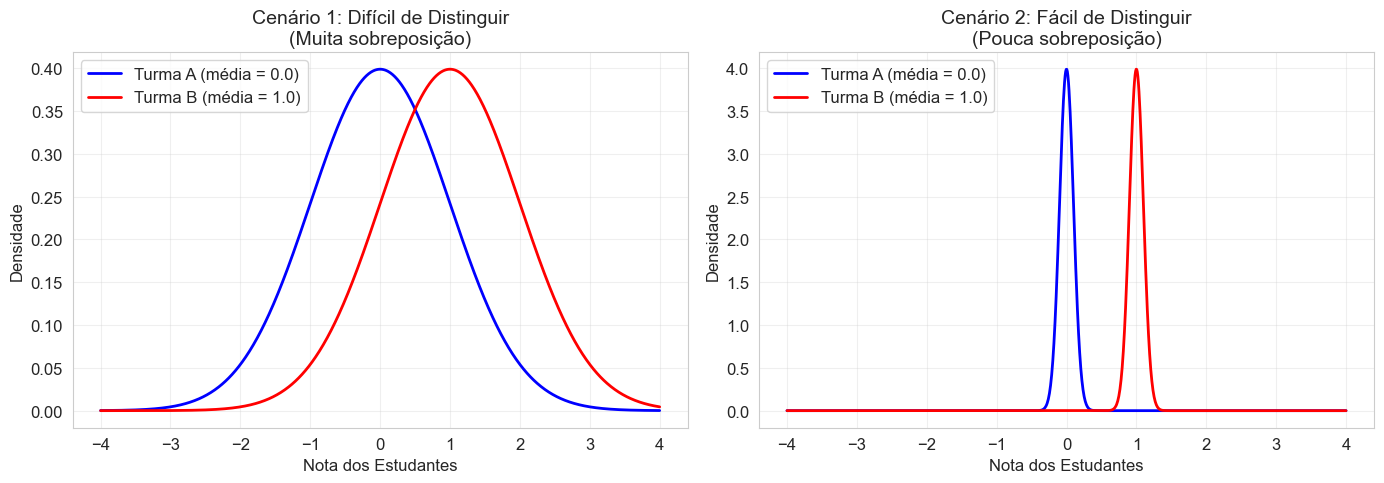

📊 Observação:
No Cenário 1: As turmas se misturam muito - difícil saber se são diferentes
No Cenário 2: As turmas são bem separadas - claramente diferentes

🎯 O teste t nos ajuda a decidir qual cenário temos!


In [12]:
# Criando um gráfico para mostrar a diferença
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Valores para os gráficos
x = np.linspace(-4.0, 4.0, 1000)

# Cenário 1: Grupos com muita sobreposição (difícil de distinguir)
ax1.plot(x, stats.norm.pdf(x, 0.0, 1.0), label='Turma A (média = 0.0)', color='blue', linewidth=2)
ax1.plot(x, stats.norm.pdf(x, 1.0, 1.0), label='Turma B (média = 1.0)', color='red', linewidth=2)
ax1.set_title('Cenário 1: Difícil de Distinguir\n(Muita sobreposição)', fontsize=14)
ax1.set_xlabel('Nota dos Estudantes')
ax1.set_ylabel('Densidade')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cenário 2: Grupos com pouca sobreposição (fácil de distinguir)
ax2.plot(x, stats.norm.pdf(x, 0.0, 0.1), label='Turma A (média = 0.0)', color='blue', linewidth=2)
ax2.plot(x, stats.norm.pdf(x, 1.0, 0.1), label='Turma B (média = 1.0)', color='red', linewidth=2)
ax2.set_title('Cenário 2: Fácil de Distinguir\n(Pouca sobreposição)', fontsize=14)
ax2.set_xlabel('Nota dos Estudantes')
ax2.set_ylabel('Densidade')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Observação:")
print("No Cenário 1: As turmas se misturam muito - difícil saber se são diferentes")
print("No Cenário 2: As turmas são bem separadas - claramente diferentes")
print("\n🎯 O teste t nos ajuda a decidir qual cenário temos!")

## Exemplo Prático: Comparando Dois Métodos de Ensino

Vamos criar dados simulados para entender melhor:

In [3]:
# Simulando notas de duas turmas
np.random.seed(42)  # Para resultados reproduzíveis

# Turma A: Método tradicional (30 alunos)
# Média = 5, desvio padrão = 2
turma_a = np.random.normal(5, 2, 30)

# Turma B: Método novo (30 alunos) 
# Média = 6, desvio padrão = 2
turma_b = np.random.normal(6, 2, 30)

print("📚 Dados das Turmas:")
print(f"Turma A - Método Tradicional:")
print(f"  Média: {np.mean(turma_a):.2f}")
print(f"  Desvio Padrão: {np.std(turma_a, ddof=1):.2f}")
print(f"  Número de alunos: {len(turma_a)}")

print(f"\nTurma B - Método Novo:")
print(f"  Média: {np.mean(turma_b):.2f}")
print(f"  Desvio Padrão: {np.std(turma_b, ddof=1):.2f}")
print(f"  Número de alunos: {len(turma_b)}")

print(f"\n🤔 Pergunta: A diferença de {np.mean(turma_b) - np.mean(turma_a):.2f} pontos é significativa?")

📚 Dados das Turmas:
Turma A - Método Tradicional:
  Média: 4.62
  Desvio Padrão: 1.80
  Número de alunos: 30

Turma B - Método Novo:
  Média: 5.76
  Desvio Padrão: 1.86
  Número de alunos: 30

🤔 Pergunta: A diferença de 1.13 pontos é significativa?


## Visualizando os Dados

Antes de fazer o teste, vamos ver como os dados se parecem:

C:\Users\gusgo\AppData\Local\Temp\ipykernel_18456\2836198132.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Turma A\n(Tradicional)', 'Turma B\n(Novo)'])
C:\Users\gusgo\AppData\Local\Temp\ipykernel_18456\2836198132.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(['Turma A\n(Tradicional)', 'Turma B\n(Novo)'])
C:\Users\gusgo\AppData\Local\Temp\ipykernel_18456\2836198132.py:55: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\gusgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Use

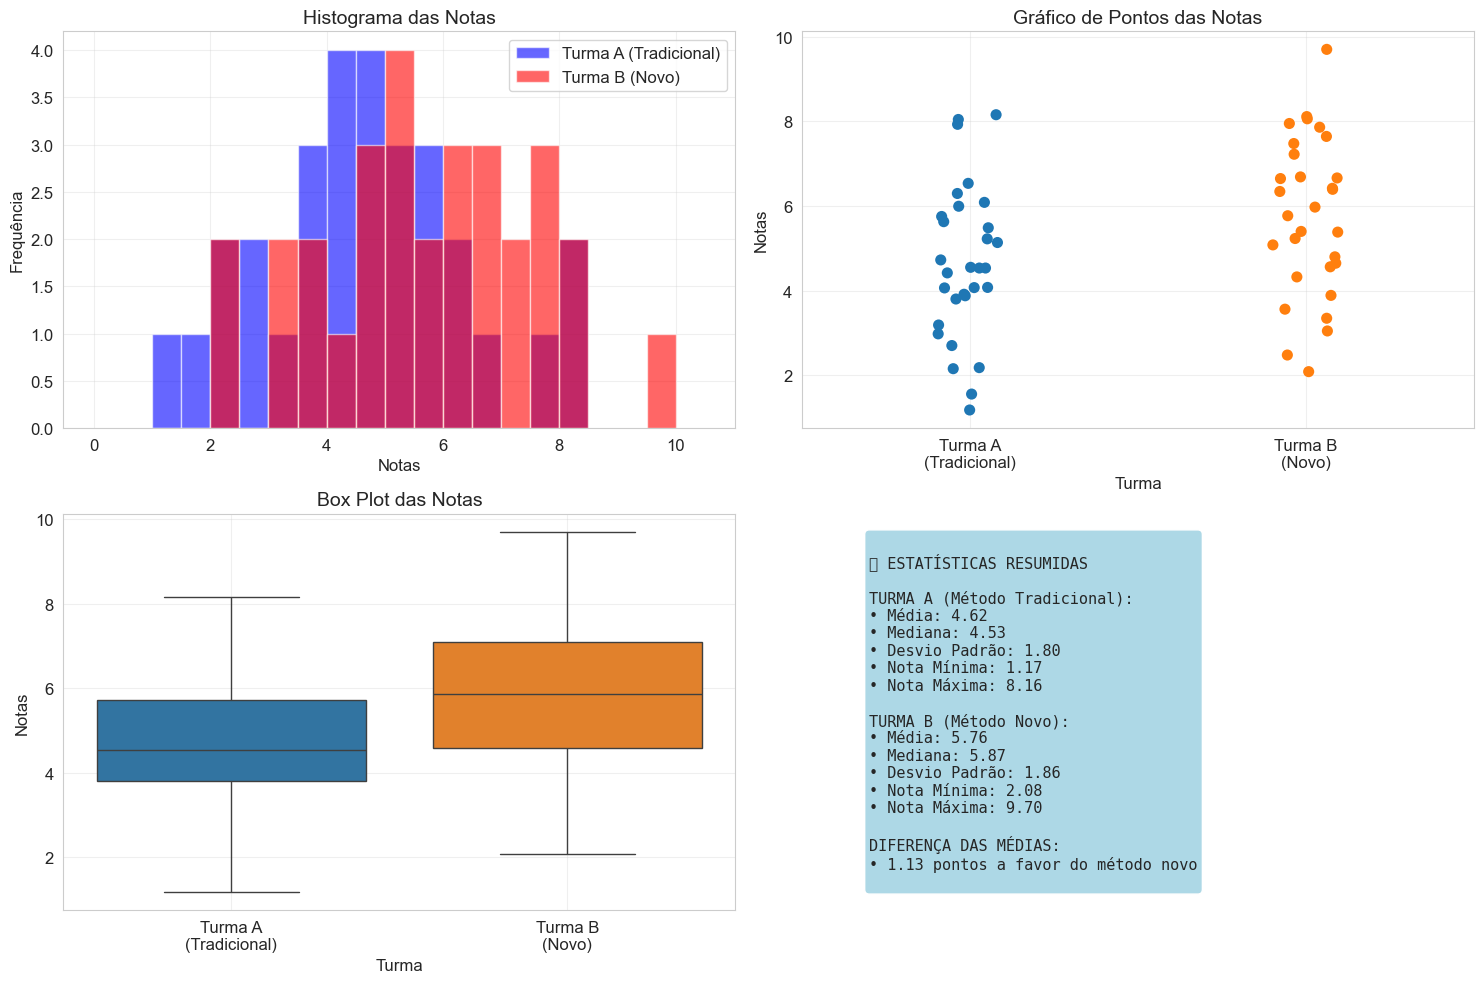

In [4]:
# Criando visualizações dos dados
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. Histograma
bins = np.arange(0, 11, 0.5)
ax1.hist(turma_a, bins=bins, color='blue', alpha=0.6, label='Turma A (Tradicional)')
ax1.hist(turma_b, bins=bins, color='red', alpha=0.6, label='Turma B (Novo)')
ax1.set_title('Histograma das Notas', fontsize=14)
ax1.set_xlabel('Notas')
ax1.set_ylabel('Frequência')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Gráfico de pontos
sns.stripplot(data=[turma_a, turma_b], ax=ax2, size=8)
ax2.set_title('Gráfico de Pontos das Notas', fontsize=14)
ax2.set_xlabel('Turma')
ax2.set_ylabel('Notas')
ax2.set_xticklabels(['Turma A\n(Tradicional)', 'Turma B\n(Novo)'])
ax2.grid(True, alpha=0.3)

# 3. Box plot
sns.boxplot(data=[turma_a, turma_b], ax=ax3)
ax3.set_title('Box Plot das Notas', fontsize=14)
ax3.set_xlabel('Turma')
ax3.set_ylabel('Notas')
ax3.set_xticklabels(['Turma A\n(Tradicional)', 'Turma B\n(Novo)'])
ax3.grid(True, alpha=0.3)

# 4. Estatísticas resumidas
ax4.axis('off')
estatisticas = f"""
📊 ESTATÍSTICAS RESUMIDAS

TURMA A (Método Tradicional):
• Média: {np.mean(turma_a):.2f}
• Mediana: {np.median(turma_a):.2f}
• Desvio Padrão: {np.std(turma_a, ddof=1):.2f}
• Nota Mínima: {np.min(turma_a):.2f}
• Nota Máxima: {np.max(turma_a):.2f}

TURMA B (Método Novo):
• Média: {np.mean(turma_b):.2f}
• Mediana: {np.median(turma_b):.2f}
• Desvio Padrão: {np.std(turma_b, ddof=1):.2f}
• Nota Mínima: {np.min(turma_b):.2f}
• Nota Máxima: {np.max(turma_b):.2f}

DIFERENÇA DAS MÉDIAS:
• {np.mean(turma_b) - np.mean(turma_a):.2f} pontos a favor do método novo
"""
ax4.text(0.1, 0.5, estatisticas, fontsize=11, verticalalignment='center', 
         fontfamily='monospace', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

plt.tight_layout()
plt.show()

## Teste $t$ para Amostras Independentes

### O que é?
Usamos este teste quando queremos comparar as médias de **dois grupos diferentes** de pessoas ou objetos.

### Quando usar?
- Comparar duas turmas diferentes
- Comparar homens vs mulheres
- Comparar grupo que recebeu medicamento vs grupo que recebeu placebo

### Como funciona?
O teste responde à pergunta: **"As médias dos dois grupos são realmente diferentes ou a diferença é apenas coincidência?"**

### Hipóteses:
- **Hipótese Nula (H₀)**: As médias dos dois grupos são iguais
- **Hipótese Alternativa (H₁)**: As médias dos dois grupos são diferentes

In [5]:
# Realizando o teste t para amostras independentes
estatistica_t, valor_p = stats.ttest_ind(turma_a, turma_b)

print("🔍 TESTE T PARA AMOSTRAS INDEPENDENTES")
print("="*50)
print(f"Estatística t: {estatistica_t:.4f}")
print(f"Valor p: {valor_p:.4f}")
print("="*50)

# Interpretação
alpha = 0.05  # Nível de significância (5%)

print(f"\n📋 INTERPRETAÇÃO:")
print(f"\n🎯 Pergunta: O método novo é realmente melhor?")
print(f"\n💡 Como interpretar:")
print(f"• Valor p = {valor_p:.4f}")
print(f"• Nível de significância = {alpha} (5%)")

if valor_p < alpha:
    print(f"\n✅ RESULTADO: SIGNIFICATIVO!")
    print(f"• O valor p ({valor_p:.4f}) é menor que {alpha}")
    print(f"• Rejeitamos a hipótese nula")
    print(f"• CONCLUSÃO: O método novo É significativamente diferente do tradicional")
    
    if np.mean(turma_b) > np.mean(turma_a):
        print(f"• O método novo produz notas MAIS ALTAS em média")
    else:
        print(f"• O método novo produz notas MAIS BAIXAS em média")
else:
    print(f"\n❌ RESULTADO: NÃO SIGNIFICATIVO")
    print(f"• O valor p ({valor_p:.4f}) é maior que {alpha}")
    print(f"• Não rejeitamos a hipótese nula")
    print(f"• CONCLUSÃO: Não há evidência suficiente de que os métodos sejam diferentes")
    print(f"• A diferença observada pode ser apenas coincidência")

print(f"\n🧮 Em termos simples:")
print(f"• Se você repetisse este experimento 100 vezes,")
print(f"• Em {valor_p*100:.1f} dessas vezes você veria uma diferença assim por pura sorte")
print(f"• Em {(1-valor_p)*100:.1f}% das vezes, a diferença seria real")

🔍 TESTE T PARA AMOSTRAS INDEPENDENTES
Estatística t: -2.3981
Valor p: 0.0197

📋 INTERPRETAÇÃO:

🎯 Pergunta: O método novo é realmente melhor?

💡 Como interpretar:
• Valor p = 0.0197
• Nível de significância = 0.05 (5%)

✅ RESULTADO: SIGNIFICATIVO!
• O valor p (0.0197) é menor que 0.05
• Rejeitamos a hipótese nula
• CONCLUSÃO: O método novo É significativamente diferente do tradicional
• O método novo produz notas MAIS ALTAS em média

🧮 Em termos simples:
• Se você repetisse este experimento 100 vezes,
• Em 2.0 dessas vezes você veria uma diferença assim por pura sorte
• Em 98.0% das vezes, a diferença seria real


## Teste $t$ para Amostras Pareadas

### O que é?
Usamos este teste quando queremos comparar o **mesmo grupo de pessoas** em **dois momentos diferentes**.

### Quando usar?
- Antes e depois de um tratamento
- Peso antes e depois da dieta
- Notas antes e depois de um curso
- Pressão arterial antes e depois do exercício

### Exemplo Prático: Curso de Reforço
Imagine que temos 30 estudantes que fizeram um teste, depois participaram de um curso de reforço, e fizeram o teste novamente.

In [6]:
# Simulando dados de antes e depois do curso
np.random.seed(123)

# Notas ANTES do curso de reforço (mesmo grupo de 30 estudantes)
notas_antes = np.random.normal(5, 0.8, 30)

# Notas DEPOIS do curso (mesmo grupo + melhoria do curso)
# Cada aluno melhorou, mas com variação individual
melhoria_individual = np.random.normal(1.2, 0.5, 30)  # Melhoria média de 1.2 pontos
notas_depois = notas_antes + melhoria_individual

print("📚 EXPERIMENTO: CURSO DE REFORÇO")
print("="*40)
print(f"Número de estudantes: {len(notas_antes)}")
print(f"\nANTES do curso:")
print(f"  Média: {np.mean(notas_antes):.2f}")
print(f"  Desvio Padrão: {np.std(notas_antes, ddof=1):.2f}")
print(f"\nDEPOIS do curso:")
print(f"  Média: {np.mean(notas_depois):.2f}")
print(f"  Desvio Padrão: {np.std(notas_depois, ddof=1):.2f}")
print(f"\nMELHORIA MÉDIA: {np.mean(notas_depois) - np.mean(notas_antes):.2f} pontos")

# Calculando a diferença para cada estudante
diferenca_individual = notas_depois - notas_antes
print(f"\n📊 ANÁLISE INDIVIDUAL:")
print(f"Melhoria média por estudante: {np.mean(diferenca_individual):.2f}")
print(f"Estudantes que melhoraram: {sum(diferenca_individual > 0)} de {len(diferenca_individual)}")
print(f"Estudantes que pioraram: {sum(diferenca_individual < 0)} de {len(diferenca_individual)}")
print(f"Maior melhoria: {np.max(diferenca_individual):.2f} pontos")
print(f"Maior piora: {np.min(diferenca_individual):.2f} pontos")

📚 EXPERIMENTO: CURSO DE REFORÇO
Número de estudantes: 30

ANTES do curso:
  Média: 5.04
  Desvio Padrão: 0.95

DEPOIS do curso:
  Média: 6.31
  Desvio Padrão: 1.06

MELHORIA MÉDIA: 1.27 pontos

📊 ANÁLISE INDIVIDUAL:
Melhoria média por estudante: 1.27
Estudantes que melhoraram: 29 de 30
Estudantes que pioraram: 1 de 30
Maior melhoria: 2.40 pontos
Maior piora: -0.20 pontos


C:\Users\gusgo\AppData\Local\Temp\ipykernel_18456\3351232194.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Antes do\nCurso', 'Depois do\nCurso'])


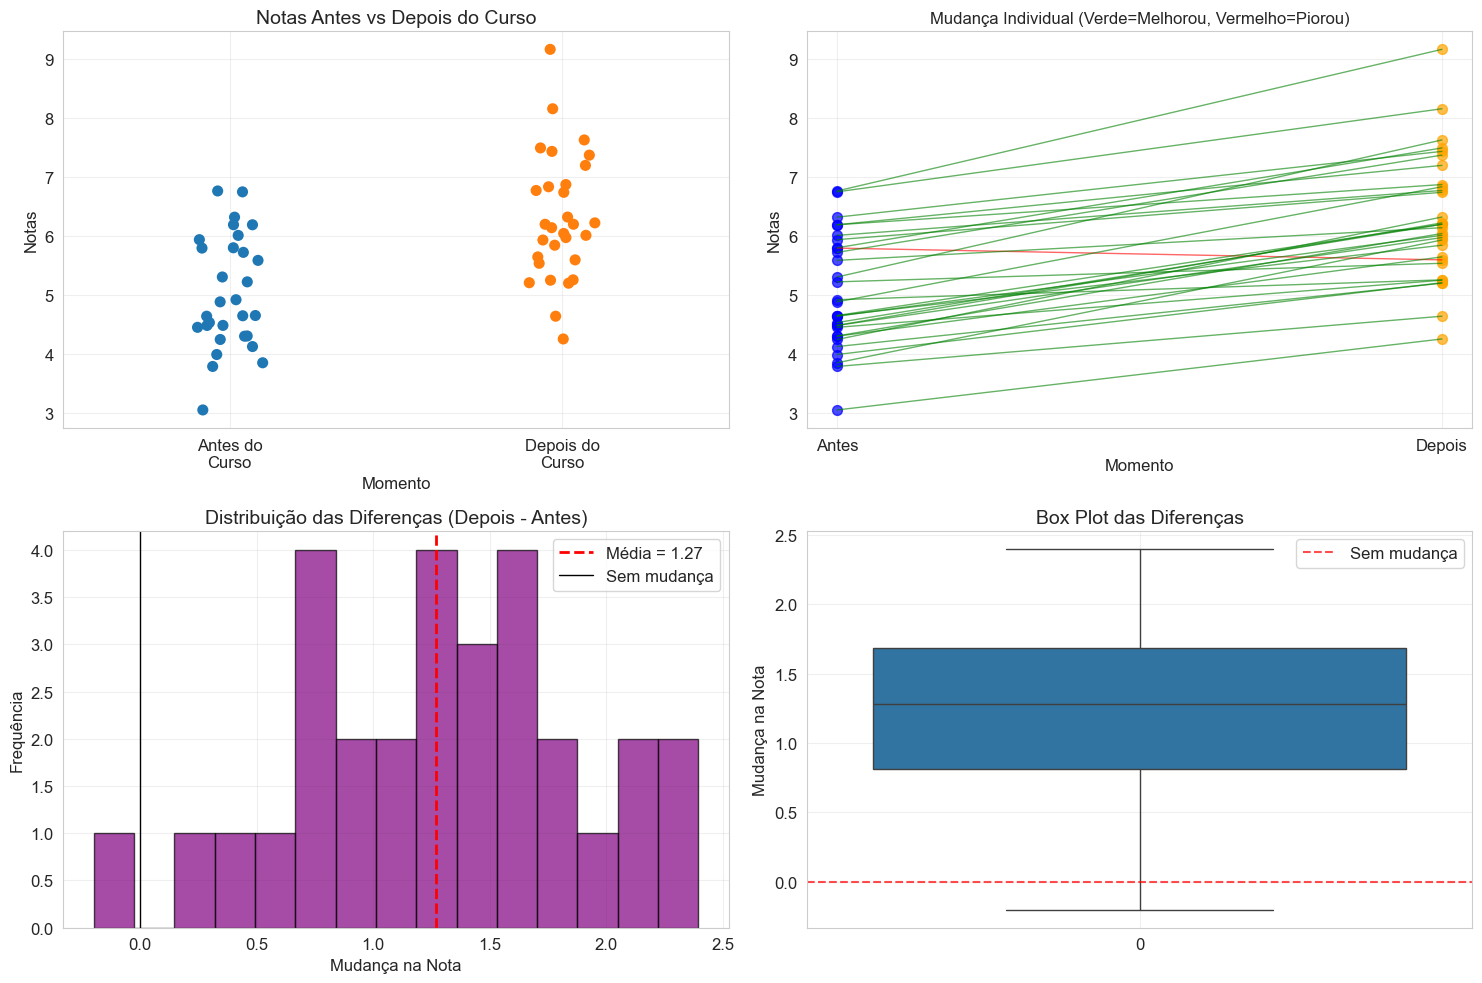

In [7]:
# Visualizando os dados pareados
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. Gráfico de pontos pareados
sns.stripplot(data=[notas_antes, notas_depois], ax=ax1, size=8)
ax1.set_title('Notas Antes vs Depois do Curso', fontsize=14)
ax1.set_xlabel('Momento')
ax1.set_ylabel('Notas')
ax1.set_xticklabels(['Antes do\nCurso', 'Depois do\nCurso'])
ax1.grid(True, alpha=0.3)

# 2. Gráfico de linhas conectando antes e depois
for i in range(len(notas_antes)):
    cor = 'green' if notas_depois[i] > notas_antes[i] else 'red'
    ax2.plot([0, 1], [notas_antes[i], notas_depois[i]], color=cor, alpha=0.6, linewidth=1)

ax2.scatter([0]*len(notas_antes), notas_antes, color='blue', alpha=0.7, s=50)
ax2.scatter([1]*len(notas_depois), notas_depois, color='orange', alpha=0.7, s=50)
ax2.set_title('Mudança Individual (Verde=Melhorou, Vermelho=Piorou)', fontsize=12)
ax2.set_xlabel('Momento')
ax2.set_ylabel('Notas')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Antes', 'Depois'])
ax2.grid(True, alpha=0.3)

# 3. Histograma das diferenças
ax3.hist(diferenca_individual, bins=15, color='purple', alpha=0.7, edgecolor='black')
ax3.axvline(np.mean(diferenca_individual), color='red', linestyle='--', linewidth=2, 
           label=f'Média = {np.mean(diferenca_individual):.2f}')
ax3.axvline(0, color='black', linestyle='-', linewidth=1, label='Sem mudança')
ax3.set_title('Distribuição das Diferenças (Depois - Antes)', fontsize=14)
ax3.set_xlabel('Mudança na Nota')
ax3.set_ylabel('Frequência')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Box plot das diferenças
sns.boxplot(data=[diferenca_individual], ax=ax4)
ax4.set_title('Box Plot das Diferenças', fontsize=14)
ax4.set_xlabel('')
ax4.set_ylabel('Mudança na Nota')
ax4.axhline(0, color='red', linestyle='--', alpha=0.7, label='Sem mudança')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Realizando o teste t para amostras pareadas
estatistica_t_pareado, valor_p_pareado = stats.ttest_rel(notas_antes, notas_depois)

print("🔍 TESTE T PARA AMOSTRAS PAREADAS")
print("="*50)
print(f"Estatística t: {estatistica_t_pareado:.4f}")
print(f"Valor p: {valor_p_pareado:.6f}")
print("="*50)

# Interpretação detalhada
alpha = 0.05

print(f"\n📋 INTERPRETAÇÃO DETALHADA:")
print(f"\n🎯 Pergunta: O curso de reforço realmente ajudou os estudantes?")
print(f"\n📊 Dados observados:")
print(f"• Melhoria média: {np.mean(diferenca_individual):.2f} pontos")
print(f"• {sum(diferenca_individual > 0)} de {len(diferenca_individual)} estudantes melhoraram")
print(f"• Porcentagem que melhorou: {(sum(diferenca_individual > 0)/len(diferenca_individual)*100):.1f}%")

print(f"\n🔬 Resultado do teste:")
print(f"• Valor p = {valor_p_pareado:.6f}")
print(f"• Nível de significância = {alpha} (5%)")

if valor_p_pareado < alpha:
    print(f"\n✅ RESULTADO: ALTAMENTE SIGNIFICATIVO!")
    print(f"• O valor p ({valor_p_pareado:.6f}) é muito menor que {alpha}")
    print(f"• Rejeitamos a hipótese nula")
    print(f"• CONCLUSÃO: O curso de reforço SIM teve efeito significativo")
    
    if np.mean(diferenca_individual) > 0:
        print(f"• O curso MELHOROU as notas significativamente")
        print(f"• Melhoria média: {np.mean(diferenca_individual):.2f} pontos")
    else:
        print(f"• O curso PIOROU as notas significativamente")
        
else:
    print(f"\n❌ RESULTADO: NÃO SIGNIFICATIVO")
    print(f"• O valor p ({valor_p_pareado:.6f}) é maior que {alpha}")
    print(f"• Não rejeitamos a hipótese nula")
    print(f"• CONCLUSÃO: Não há evidência suficiente de que o curso teve efeito")
    print(f"• A melhoria observada pode ser apenas coincidência")

print(f"\n🎲 Probabilidade de ser coincidência:")
print(f"• Se o curso NÃO tivesse efeito, a chance de ver essa melhoria por acaso seria: {valor_p_pareado:.6f}")
print(f"• Isso é {valor_p_pareado*100:.4f}% de chance")
print(f"• Em outras palavras: {valor_p_pareado:.6f} = aproximadamente {1/valor_p_pareado if valor_p_pareado > 0 else float('inf'):.0f} em 1 milhão")

🔍 TESTE T PARA AMOSTRAS PAREADAS
Estatística t: -11.2930
Valor p: 0.000000

📋 INTERPRETAÇÃO DETALHADA:

🎯 Pergunta: O curso de reforço realmente ajudou os estudantes?

📊 Dados observados:
• Melhoria média: 1.27 pontos
• 29 de 30 estudantes melhoraram
• Porcentagem que melhorou: 96.7%

🔬 Resultado do teste:
• Valor p = 0.000000
• Nível de significância = 0.05 (5%)

✅ RESULTADO: ALTAMENTE SIGNIFICATIVO!
• O valor p (0.000000) é muito menor que 0.05
• Rejeitamos a hipótese nula
• CONCLUSÃO: O curso de reforço SIM teve efeito significativo
• O curso MELHOROU as notas significativamente
• Melhoria média: 1.27 pontos

🎲 Probabilidade de ser coincidência:
• Se o curso NÃO tivesse efeito, a chance de ver essa melhoria por acaso seria: 0.000000
• Isso é 0.0000% de chance
• Em outras palavras: 0.000000 = aproximadamente 256195179909 em 1 milhão


## Diferenças Principais Entre os Dois Tipos de Teste

### 📊 Resumo Comparativo

In [9]:
# Tabela comparativa
import pandas as pd

comparacao = {
    'Aspecto': [
        'Grupos',
        'Pessoas',
        'Exemplo',
        'Pergunta típica',
        'Vantagem',
        'Quando usar',
        'Função Python'
    ],
    'Amostras Independentes': [
        'Dois grupos diferentes',
        'Pessoas diferentes em cada grupo',
        'Turma A vs Turma B',
        'Os grupos são diferentes?',
        'Evita efeito de aprendizado',
        'Comparar grupos naturalmente diferentes',
        'stats.ttest_ind(grupo1, grupo2)'
    ],
    'Amostras Pareadas': [
        'Mesmo grupo, dois momentos',
        'Mesmas pessoas medidas duas vezes',
        'Antes vs Depois do tratamento',
        'Houve mudança?',
        'Controla diferenças individuais',
        'Medir mudança ao longo do tempo',
        'stats.ttest_rel(antes, depois)'
    ]
}

df_comparacao = pd.DataFrame(comparacao)
print("📋 TABELA COMPARATIVA DOS TIPOS DE TESTE T")
print("="*80)
print(df_comparacao.to_string(index=False))

print("\n\n💡 DICA IMPORTANTE:")
print("• Use INDEPENDENTES quando quiser comparar grupos diferentes")
print("• Use PAREADAS quando quiser medir mudança no mesmo grupo")
print("• Amostras pareadas são geralmente mais poderosas (detectam diferenças menores)")

📋 TABELA COMPARATIVA DOS TIPOS DE TESTE T
        Aspecto                  Amostras Independentes                 Amostras Pareadas
         Grupos                  Dois grupos diferentes        Mesmo grupo, dois momentos
        Pessoas        Pessoas diferentes em cada grupo Mesmas pessoas medidas duas vezes
        Exemplo                      Turma A vs Turma B     Antes vs Depois do tratamento
Pergunta típica               Os grupos são diferentes?                    Houve mudança?
       Vantagem             Evita efeito de aprendizado   Controla diferenças individuais
    Quando usar Comparar grupos naturalmente diferentes   Medir mudança ao longo do tempo
  Função Python         stats.ttest_ind(grupo1, grupo2)    stats.ttest_rel(antes, depois)


💡 DICA IMPORTANTE:
• Use INDEPENDENTES quando quiser comparar grupos diferentes
• Use PAREADAS quando quiser medir mudança no mesmo grupo
• Amostras pareadas são geralmente mais poderosas (detectam diferenças menores)


## 🧮 Como Interpretar os Resultados

### O que é o Valor p?
O valor p é a probabilidade de você ver uma diferença pelo menos tão grande quanto a observada, **assumindo que não há diferença real**.

### Regra Prática:
- **p < 0.05**: Diferença significativa (menos de 5% de chance de ser coincidência)
- **p ≥ 0.05**: Diferença não significativa (mais de 5% de chance de ser coincidência)

### Analogia Simples:
Imagine que você joga uma moeda 10 vezes e sai 8 caras. Você suspeita que a moeda é viciada.
- O valor p te diz: "Se a moeda fosse honesta, qual a chance de sair 8 ou mais caras?"
- Se essa chance for muito baixa (p < 0.05), você conclui que a moeda provavelmente é viciada

In [10]:
# Demonstração de diferentes valores p e suas interpretações
valores_p_exemplo = [0.001, 0.01, 0.05, 0.10, 0.50, 0.80]
interpretacoes = []

for p in valores_p_exemplo:
    if p < 0.001:
        interpretacao = "Extremamente significativo - quase certeza de diferença real"
        emoji = "🎯🎯🎯"
    elif p < 0.01:
        interpretacao = "Altamente significativo - muito provável que seja diferença real"
        emoji = "🎯🎯"
    elif p < 0.05:
        interpretacao = "Significativo - provavelmente diferença real"
        emoji = "🎯"
    elif p < 0.10:
        interpretacao = "Marginalmente significativo - evidência fraca"
        emoji = "🤔"
    else:
        interpretacao = "Não significativo - pode ser coincidência"
        emoji = "❌"
    
    interpretacoes.append((p, interpretacao, emoji))

print("📊 GUIA DE INTERPRETAÇÃO DOS VALORES P")
print("="*60)
for p, interp, emoji in interpretacoes:
    porcentagem = p * 100
    chance = f"1 em {1/p:.0f}" if p > 0 else "impossível"
    print(f"{emoji} p = {p:5.3f} ({porcentagem:5.1f}%) - {interp}")
    print(f"    Chance de ser coincidência: {chance}")
    print()

print("\n💭 LEMBRE-SE:")
print("• Valor p NÃO é a probabilidade da hipótese estar certa")
print("• Valor p É a probabilidade de ver esses dados por acaso")
print("• Quanto menor o p, mais forte a evidência contra a hipótese nula")

📊 GUIA DE INTERPRETAÇÃO DOS VALORES P
🎯🎯 p = 0.001 (  0.1%) - Altamente significativo - muito provável que seja diferença real
    Chance de ser coincidência: 1 em 1000

🎯 p = 0.010 (  1.0%) - Significativo - provavelmente diferença real
    Chance de ser coincidência: 1 em 100

🤔 p = 0.050 (  5.0%) - Marginalmente significativo - evidência fraca
    Chance de ser coincidência: 1 em 20

❌ p = 0.100 ( 10.0%) - Não significativo - pode ser coincidência
    Chance de ser coincidência: 1 em 10

❌ p = 0.500 ( 50.0%) - Não significativo - pode ser coincidência
    Chance de ser coincidência: 1 em 2

❌ p = 0.800 ( 80.0%) - Não significativo - pode ser coincidência
    Chance de ser coincidência: 1 em 1


💭 LEMBRE-SE:
• Valor p NÃO é a probabilidade da hipótese estar certa
• Valor p É a probabilidade de ver esses dados por acaso
• Quanto menor o p, mais forte a evidência contra a hipótese nula


## 🎯 Resumo Final

### O que aprendemos:

1. **Testes t servem para comparar médias** de grupos ou momentos
2. **Dois tipos principais**:
   - **Independentes**: Grupos diferentes
   - **Pareadas**: Mesmo grupo, momentos diferentes
3. **Valor p indica** a probabilidade de ver a diferença por acaso
4. **p < 0.05** geralmente indica diferença significativa

### Passos para fazer um teste t:
1. **Defina sua pergunta**: Que grupos/momentos quer comparar?
2. **Escolha o teste**: Independente ou pareado?
3. **Colete os dados**: Garanta que são adequados
4. **Execute o teste**: Use a função apropriada
5. **Interprete**: Compare p com 0.05
6. **Conclua**: Responda sua pergunta original

### Cuidados importantes:
- ⚠️ Os dados devem seguir distribuição aproximadamente normal
- ⚠️ As observações devem ser independentes
- ⚠️ Para amostras pequenas (n < 30), seja mais cauteloso
- ⚠️ Significância estatística ≠ Importância prática

### Em português simples:
**"O teste t é como um detetive estatístico que investiga se as diferenças que você vê nos seus dados são reais ou apenas coincidência!"** 🕵️‍♂️